In [1]:
!pip install mlflow albumentations -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 57.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 48.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 939.7/939.7 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.

In [2]:
import os

if not os.path.exists("skin-dataset-classification"):
    !git clone https://github.com/2245-RN-ITBA/skin-dataset-classification.git

os.chdir("skin-dataset-classification")
print(os.getcwd())
print(os.listdir("data/Split_smol"))

Cloning into 'skin-dataset-classification'...
remote: Enumerating objects: 934, done.
remote: Counting objects: 100% (23/23), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 934 (delta 17), reused 15 (delta 15), pack-reused 911 (from 2)
Receiving objects: 100% (934/934), 222.43 MiB | 33.40 MiB/s, done.
Resolving deltas: 100% (31/31), done.
/content/skin-dataset-classification
['val', 'train']


In [3]:
import warnings
warnings.filterwarnings('ignore')

import hashlib
import shutil
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from PIL import Image
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from tqdm import tqdm
import io

import mlflow
import mlflow.pytorch
from torch.utils.tensorboard import SummaryWriter
import torchvision.utils as vutils

mlflow.set_tracking_uri("sqlite:///mlflow_tp2.db")
mlflow.set_experiment("CNN_Lesiones_Dermatologicas")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

2026/06/22 13:28:10 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/22 13:28:11 INFO mlflow.store.db.utils: Updating database tables
2026/06/22 13:28:14 INFO mlflow.tracking.fluent: Experiment with name 'CNN_Lesiones_Dermatologicas' does not exist. Creating a new experiment.


Device: cpu


## Limpieza del dataset

In [4]:
def compute_md5(filepath):
    """Calcula el hash MD5 del contenido binario de un archivo."""
    hasher = hashlib.md5()
    with open(filepath, "rb") as f:
        hasher.update(f.read())
    return hasher.hexdigest()


def collect_all_images(base_dirs):
    """
    Recolecta todas las imágenes de los directorios dados.
    Devuelve una lista de dicts con path, clase, split de origen y hash.
    """
    records = []
    for split_name, base_dir in base_dirs.items():
        base_path = Path(base_dir)
        for class_dir in sorted(base_path.iterdir()):
            if not class_dir.is_dir():
                continue
            for img_path in class_dir.iterdir():
                if img_path.suffix.lower() not in (".png", ".jpg", ".jpeg"):
                    continue
                records.append({
                    "path": str(img_path),
                    "class": class_dir.name,
                    "origin_split": split_name,
                    "hash": compute_md5(img_path),
                })
    return pd.DataFrame(records)

In [5]:
base_dirs = {
    "train": "data/Split_smol/train",
    "val":   "data/Split_smol/val",
}

df_all = collect_all_images(base_dirs)
print(f"Total de imágenes encontradas: {len(df_all)}")
df_all.head()

Total de imágenes encontradas: 878


,path,class,origin_split,hash
0,data/Split_smol/train/Actinic keratosis/ISIC_0...,Actinic keratosis,train,e4897bd14f781db74fa52db712e68abf
1,data/Split_smol/train/Actinic keratosis/ISIC_0...,Actinic keratosis,train,7e77bc57d3e234fd87929089d8184f6b
2,data/Split_smol/train/Actinic keratosis/ISIC_0...,Actinic keratosis,train,49c2aac942a021dd609b2e6aee31b9a3
3,data/Split_smol/train/Actinic keratosis/ISIC_0...,Actinic keratosis,train,a71fe5a788f3bda260aefcfba95f398e
4,data/Split_smol/train/Actinic keratosis/ISIC_0...,Actinic keratosis,train,1b3d0725cd7a6b80a1f56d6106357dc3


In [6]:
# Análisis de duplicados
hash_counts = df_all["hash"].value_counts()
duplicated_hashes = hash_counts[hash_counts > 1]

print(f"Hashes únicos: {df_all['hash'].nunique()}")
print(f"Hashes duplicados (aparecen 2+ veces): {len(duplicated_hashes)}")
print(f"Total de imágenes 'extra' por duplicación: {duplicated_hashes.sum() - len(duplicated_hashes)}")

# Duplicados dentro de val
df_val_only = df_all[df_all["origin_split"] == "val"]
val_dup_hashes = df_val_only["hash"].value_counts()
val_dup_hashes = val_dup_hashes[val_dup_hashes > 1]
print(f"\nDuplicados específicamente dentro de val: {len(val_dup_hashes)} hashes repetidos")

# Duplicados entre train y val (data leakage)
hash_to_splits = df_all.groupby("hash")["origin_split"].apply(set)
leakage_hashes = hash_to_splits[hash_to_splits.apply(lambda s: "train" in s and "val" in s)]
print(f"Hashes presentes en train Y val (data leakage): {len(leakage_hashes)}")

Hashes únicos: 844
Hashes duplicados (aparecen 2+ veces): 34
Total de imágenes 'extra' por duplicación: 34

Duplicados específicamente dentro de val: 0 hashes repetidos
Hashes presentes en train Y val (data leakage): 33


In [7]:
df_unique = df_all.drop_duplicates(subset="hash", keep="first").reset_index(drop=True)

print(f"Imágenes antes de deduplicar: {len(df_all)}")
print(f"Imágenes después de deduplicar: {len(df_unique)}")
print(f"Imágenes eliminadas: {len(df_all) - len(df_unique)}")
print("\nDistribución de clases después de deduplicar:")
print(df_unique["class"].value_counts())

Imágenes antes de deduplicar: 878
Imágenes después de deduplicar: 844
Imágenes eliminadas: 34

Distribución de clases después de deduplicar:
class
Actinic keratosis             100
Benign keratosis              100
Dermatofibroma                100
Melanocytic nevus             100
Melanoma                      100
Vascular lesion               100
Squamous cell carcinoma       100
Atopic Dermatitis              80
Tinea Ringworm Candidiasis     64
Name: count, dtype: int64


## Re-split con estratificación



In [8]:
VAL_SIZE = 0.2
RANDOM_STATE = 42

df_train_new, df_val_new = train_test_split(
    df_unique,
    test_size=VAL_SIZE,
    random_state=RANDOM_STATE,
    stratify=df_unique["class"]
)

print(f"Train: {len(df_train_new)} imágenes")
print(f"Val:   {len(df_val_new)} imágenes")
print("\nDistribución de clases — Train:")
print(df_train_new["class"].value_counts(normalize=True).round(3))
print("\nDistribución de clases — Val:")
print(df_val_new["class"].value_counts(normalize=True).round(3))

Train: 675 imágenes
Val:   169 imágenes

Distribución de clases — Train:
class
Actinic keratosis             0.119
Benign keratosis              0.119
Melanoma                      0.119
Squamous cell carcinoma       0.119
Dermatofibroma                0.119
Vascular lesion               0.119
Melanocytic nevus             0.119
Atopic Dermatitis             0.095
Tinea Ringworm Candidiasis    0.076
Name: proportion, dtype: float64

Distribución de clases — Val:
class
Melanocytic nevus             0.118
Actinic keratosis             0.118
Benign keratosis              0.118
Melanoma                      0.118
Vascular lesion               0.118
Squamous cell carcinoma       0.118
Dermatofibroma                0.118
Atopic Dermatitis             0.095
Tinea Ringworm Candidiasis    0.077
Name: proportion, dtype: float64


In [9]:
# Reconstruir las carpetas train/val limpias
NEW_DATA_DIR = "data/Split_clean"

def rebuild_split(df_split, split_name, base_out_dir):
    for _, row in df_split.iterrows():
        out_dir = Path(base_out_dir) / split_name / row["class"]
        out_dir.mkdir(parents=True, exist_ok=True)
        src = Path(row["path"])
        dst = out_dir / src.name
        if not dst.exists():
            shutil.copy(src, dst)

if not os.path.exists(NEW_DATA_DIR):
    rebuild_split(df_train_new, "train", NEW_DATA_DIR)
    rebuild_split(df_val_new,   "val",   NEW_DATA_DIR)
    print(f"Dataset limpio reconstruido en: {NEW_DATA_DIR}")
else:
    print(f"{NEW_DATA_DIR} ya existe, se omite la reconstrucción.")

train_dir = os.path.join(NEW_DATA_DIR, "train")
val_dir   = os.path.join(NEW_DATA_DIR, "val")

print(f"\ntrain_dir = {train_dir}")
print(f"val_dir   = {val_dir}")

Dataset limpio reconstruido en: data/Split_clean

train_dir = data/Split_clean/train
val_dir   = data/Split_clean/val


In [10]:
# Verificación final: confirmar que no quedan duplicados ni leakage en el dataset limpio
df_check = collect_all_images({"train": train_dir, "val": val_dir})
hash_to_splits_check = df_check.groupby("hash")["origin_split"].apply(set)
leakage_check = hash_to_splits_check[hash_to_splits_check.apply(lambda s: "train" in s and "val" in s)]

print(f"Total imágenes en dataset limpio: {len(df_check)}")
print(f"Hashes duplicados restantes: {(df_check['hash'].value_counts() > 1).sum()}")
print(f"Leakage train/val restante: {len(leakage_check)}")
assert len(leakage_check) == 0, "Todavía hay leakage entre train y val!"
print("\n✓ Dataset limpio: sin duplicados, sin leakage, split estratificado.")

Total imágenes en dataset limpio: 844
Hashes duplicados restantes: 0
Leakage train/val restante: 0

✓ Dataset limpio: sin duplicados, sin leakage, split estratificado.


## Dataset

In [11]:
class CustomImageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir  = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels      = []

        class_names = sorted(os.listdir(root_dir))
        self.class_to_idx = {cls: idx for idx, cls in enumerate(class_names)}

        for cls in class_names:
            cls_dir = os.path.join(root_dir, cls)
            for fname in os.listdir(cls_dir):
                if fname.lower().endswith((".png", ".jpg", ".jpeg")):
                    self.image_paths.append(os.path.join(cls_dir, fname))
                    self.labels.append(cls)

        self.label_encoder = LabelEncoder()
        self.labels = self.label_encoder.fit_transform(self.labels)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = np.array(Image.open(self.image_paths[idx]).convert("RGB"))
        label = self.labels[idx]
        if self.transform:
            augmented = self.transform(image=image)
            image = augmented["image"]
        return image, label

In [12]:
def plot_to_tensorboard(fig, writer, tag, step):
    buf = io.BytesIO()
    fig.savefig(buf, format='png')
    buf.seek(0)
    image = Image.open(buf).convert("RGB")
    image = np.array(image)
    image = torch.tensor(image).permute(2, 0, 1) / 255.0
    writer.add_image(tag, image, global_step=step)
    plt.close(fig)


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def log_classification_report(model, loader, writer, device, classes, step, prefix="val"):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    cm = confusion_matrix(all_labels, all_preds)
    fig_cm, ax = plt.subplots(figsize=(6, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
    ax.set_title(f'{prefix.title()} - Confusion Matrix')
    plot_to_tensorboard(fig_cm, writer, f"{prefix}/confusion_matrix", step)

    cls_report = classification_report(all_labels, all_preds, target_names=classes, zero_division=0)
    writer.add_text(f"{prefix}/classification_report", f"<pre>{cls_report}</pre>", step)
    return cls_report


def evaluate(model, loader, writer, device, classes, criterion, epoch=None, prefix="val", log_report=False):
    if log_report and epoch is not None:
        log_classification_report(model, loader, writer, device, classes, step=epoch, prefix=prefix)

    model.eval()
    correct, total, loss_sum = 0, 0, 0.0
    with torch.no_grad():
        for i, (images, labels) in enumerate(loader):
            images, labels = images.to(device), labels.to(device)
            outputs  = model(images)
            loss     = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)
            loss_sum += loss.item()
            correct  += (preds == labels).sum().item()
            total    += labels.size(0)
            if i == 0 and epoch is not None:
                img_grid = vutils.make_grid(images[:8].cpu(), normalize=True)
                writer.add_image(f"{prefix}/images", img_grid, global_step=epoch)

    acc = 100.0 * correct / total
    avg_loss = loss_sum / len(loader)
    if epoch is not None:
        writer.add_scalar(f"{prefix}/loss", avg_loss, epoch)
        writer.add_scalar(f"{prefix}/accuracy", acc, epoch)
    return avg_loss, acc

## Arquitectura


```
Entrada (3, 128, 128)
→ Conv(96,  11x11, stride=4) + ReLU + MaxPool(3,2)
→ Conv(256, 5x5,  padding=2) + ReLU + MaxPool(3,2)
→ Conv(384, 3x3,  padding=1) + ReLU
→ Conv(384, 3x3,  padding=1) + ReLU
→ Conv(256, 3x3,  padding=1) + ReLU + MaxPool(3,2)
→ AdaptiveAvgPool(6,6) → Flatten
→ Linear(256*6*6 → 4096) + ReLU + Dropout
→ Linear(4096 → 4096) + ReLU + Dropout
→ Linear(4096 → num_classes)
```


In [13]:
class AlexNetCNN(nn.Module):
    """
    CNN inspirada en AlexNet, adaptada para el dataset de lesiones dermatológicas.

    Parámetros
    ----------
    num_classes   : int   - número de clases
    dropout       : float - probabilidad de Dropout en las capas densas
    use_batchnorm : bool  - si True, agrega BatchNorm2d después de cada conv
    """
    def __init__(self, num_classes=9, dropout=0.5, use_batchnorm=True):
        super().__init__()

        def conv_block(in_c, out_c, kernel, stride=1, padding=0, pool=True):
            layers = [nn.Conv2d(in_c, out_c, kernel_size=kernel, stride=stride, padding=padding)]
            if use_batchnorm:
                layers.append(nn.BatchNorm2d(out_c))
            layers.append(nn.ReLU(inplace=True))
            if pool:
                layers.append(nn.MaxPool2d(kernel_size=3, stride=2))
            return nn.Sequential(*layers)

        self.features = nn.Sequential(
            conv_block(3,   96,  kernel=11, stride=4, padding=2, pool=True),
            conv_block(96,  256, kernel=5,  stride=1, padding=2, pool=True),
            conv_block(256, 384, kernel=3,  stride=1, padding=1, pool=False),
            conv_block(384, 384, kernel=3,  stride=1, padding=1, pool=False),
            conv_block(384, 256, kernel=3,  stride=1, padding=1, pool=True),
        )

        self.adaptive_pool = nn.AdaptiveAvgPool2d((6, 6))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=dropout),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes),
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.features(x)
        x = self.adaptive_pool(x)
        x = self.classifier(x)
        return x

In [14]:
# Verificación rápida de la arquitectura
dummy = torch.randn(2, 3, 128, 128).to(device)
m = AlexNetCNN(num_classes=9, dropout=0.5, use_batchnorm=True).to(device)
out = m(dummy)
print(f"Output shape: {out.shape}")
print(f"Parámetros entrenables: {count_parameters(m):,}")
del m, dummy

Output shape: torch.Size([2, 9])
Parámetros entrenables: 58,320,969


## Función de entrenamiento

In [15]:
def train_model(model, t_loader, v_loader, classes, epochs, lr, optimizer_name,
                 weight_decay=0.0, es_patience=7, run_name="run", log_dir_prefix="runs",
                 extra_params=None, verbose=True):
    """
    Entrena un modelo con early stopping, logueando en TensorBoard y MLflow.
    Devuelve el mejor val_accuracy alcanzado.
    """
    criterion = nn.CrossEntropyLoss()
    if optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == "SGD":
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    else:
        raise ValueError(f"Optimizer no soportado: {optimizer_name}")

    writer = SummaryWriter(log_dir=f"{log_dir_prefix}/{run_name}")

    params = {
        "model": "AlexNetCNN", "lr": lr, "optimizer": optimizer_name,
        "weight_decay": weight_decay, "epochs": epochs, "es_patience": es_patience,
        "count_params": count_parameters(model),
    }
    if extra_params:
        params.update(extra_params)

    best_val_acc, best_val_loss = 0, 0
    best_train_acc, best_train_loss = 0, 0
    best_epoch = 0

    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(params)

        for epoch in range(epochs):
            model.train()
            running_loss, correct, total = 0.0, 0, 0

            for images, labels in t_loader:
                images, labels = images.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

                running_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

            train_loss = running_loss / len(t_loader)
            train_acc = 100.0 * correct / total

            log_report = (epoch == epochs - 1)
            val_loss, val_acc = evaluate(model, v_loader, writer, device, classes,
                                          criterion, epoch=epoch, prefix="val",
                                          log_report=log_report)

            writer.add_scalar("train/loss", train_loss, epoch)
            writer.add_scalar("train/accuracy", train_acc, epoch)

            mlflow.log_metrics({
                "train_loss": train_loss, "train_accuracy": train_acc,
                "val_loss": val_loss, "val_accuracy": val_acc,
            }, step=epoch)

            if verbose:
                print(f"  Epoch {epoch+1:3d}/{epochs} | train_loss={train_loss:.4f} "
                      f"train_acc={train_acc:.1f}% | val_loss={val_loss:.4f} val_acc={val_acc:.1f}%")

            if val_acc > best_val_acc:
                best_val_acc, best_val_loss = val_acc, val_loss
                best_train_acc, best_train_loss = train_acc, train_loss
                best_epoch = epoch
                torch.save(model.state_dict(), f"best_{run_name}.pth")
                mlflow.log_artifact(f"best_{run_name}.pth")
            elif epoch > best_epoch + es_patience:
                if verbose:
                    print(f"  Early stopping en epoch {epoch+1}")
                break

        mlflow.log_metrics({
            "best_train_loss": best_train_loss, "best_train_accuracy": best_train_acc,
            "best_val_loss": best_val_loss, "best_val_accuracy": best_val_acc,
            "best_epoch": best_epoch,
        }, step=epoch + 1)

    writer.close()
    return best_val_acc, best_epoch

## Baseline



In [16]:
INPUT_SIZE = 128

baseline_train_transform = A.Compose([
    A.Resize(INPUT_SIZE, INPUT_SIZE),
    A.Normalize(),
    ToTensorV2(),
])
baseline_val_transform = A.Compose([
    A.Resize(INPUT_SIZE, INPUT_SIZE),
    A.Normalize(),
    ToTensorV2(),
])

train_dataset = CustomImageDataset(train_dir, transform=baseline_train_transform)
val_dataset   = CustomImageDataset(val_dir,   transform=baseline_val_transform)
classes = train_dataset.label_encoder.classes_
num_classes = len(classes)

t_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
v_loader = DataLoader(val_dataset,   batch_size=32)

print(f"Clases: {list(classes)}")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")

Clases: [np.str_('Actinic keratosis'), np.str_('Atopic Dermatitis'), np.str_('Benign keratosis'), np.str_('Dermatofibroma'), np.str_('Melanocytic nevus'), np.str_('Melanoma'), np.str_('Squamous cell carcinoma'), np.str_('Tinea Ringworm Candidiasis'), np.str_('Vascular lesion')]
Train: 675 | Val: 169


In [17]:
model_baseline = AlexNetCNN(num_classes=num_classes, dropout=0.5, use_batchnorm=True).to(device)

best_acc, best_ep = train_model(
    model_baseline, t_loader, v_loader, classes,
    epochs=40, lr=1e-3, optimizer_name="Adam",
    run_name="baseline_alexnet",
    extra_params={"input_size": INPUT_SIZE, "dropout": 0.5, "use_batchnorm": True,
                  "HFlip": 0.0, "VFlip": 0.0, "RBContrast": 0.0, "batch_size": 32}
)
print(f"\nBaseline — Mejor val_acc: {best_acc:.2f}% en epoch {best_ep+1}")

  Epoch   1/40 | train_loss=22.4332 train_acc=14.5% | val_loss=5.1330 val_acc=14.2%
  Epoch   2/40 | train_loss=4.3304 train_acc=14.2% | val_loss=3.0161 val_acc=15.4%
  Epoch   3/40 | train_loss=3.1797 train_acc=19.4% | val_loss=2.2934 val_acc=18.9%
  Epoch   4/40 | train_loss=2.3885 train_acc=19.9% | val_loss=2.0955 val_acc=20.7%
  Epoch   5/40 | train_loss=2.2170 train_acc=19.9% | val_loss=2.0088 val_acc=25.4%
  Epoch   6/40 | train_loss=2.0598 train_acc=23.3% | val_loss=1.9018 val_acc=25.4%
  Epoch   7/40 | train_loss=1.9932 train_acc=22.8% | val_loss=1.7252 val_acc=23.7%
  Epoch   8/40 | train_loss=1.9412 train_acc=24.6% | val_loss=1.7246 val_acc=25.4%
  Epoch   9/40 | train_loss=1.9308 train_acc=26.5% | val_loss=1.9768 val_acc=25.4%
  Epoch  10/40 | train_loss=1.9676 train_acc=21.9% | val_loss=1.6863 val_acc=27.2%
  Epoch  11/40 | train_loss=1.9072 train_acc=25.9% | val_loss=1.9194 val_acc=23.7%
  Epoch  12/40 | train_loss=1.9220 train_acc=26.4% | val_loss=1.5909 val_acc=32.0%
  E

## Experimentos de Data Augmentation



In [18]:
augment_configs = {
    "no_augment": A.Compose([
        A.Resize(INPUT_SIZE, INPUT_SIZE),
        A.Normalize(),
        ToTensorV2(),
    ]),
    "geometric_light": A.Compose([
        A.Resize(INPUT_SIZE, INPUT_SIZE),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.Normalize(),
        ToTensorV2(),
    ]),
    "geometric_color": A.Compose([
        A.Resize(INPUT_SIZE, INPUT_SIZE),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.3),
        A.Normalize(),
        ToTensorV2(),
    ]),
    "aggressive": A.Compose([
        A.Resize(INPUT_SIZE, INPUT_SIZE),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.3),
        A.Rotate(limit=30, p=0.5),
        A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.3),
        A.Normalize(),
        ToTensorV2(),
    ]),
}

val_transform_fixed = A.Compose([
    A.Resize(INPUT_SIZE, INPUT_SIZE),
    A.Normalize(),
    ToTensorV2(),
])

In [19]:
augment_results = {}

for aug_name, aug_transform in augment_configs.items():
    print(f"\n=== Augmentation: {aug_name} ===")

    t_dataset = CustomImageDataset(train_dir, transform=aug_transform)
    v_dataset = CustomImageDataset(val_dir,   transform=val_transform_fixed)
    t_load = DataLoader(t_dataset, batch_size=32, shuffle=True)
    v_load = DataLoader(v_dataset, batch_size=32)

    model = AlexNetCNN(num_classes=num_classes, dropout=0.5, use_batchnorm=True).to(device)

    best_acc, best_ep = train_model(
        model, t_load, v_load, classes,
        epochs=30, lr=1e-3, optimizer_name="Adam",
        run_name=f"augment_{aug_name}",
        extra_params={"input_size": INPUT_SIZE, "dropout": 0.5, "use_batchnorm": True,
                      "augmentation": aug_name, "batch_size": 32},
        verbose=False
    )
    augment_results[aug_name] = best_acc
    print(f"  Mejor val_acc: {best_acc:.2f}% (epoch {best_ep+1})")

print("\n=== Resumen Data Augmentation ===")
for name, acc in sorted(augment_results.items(), key=lambda x: -x[1]):
    print(f"  {name:20s}: {acc:.2f}%")


=== Augmentation: no_augment ===
  Mejor val_acc: 33.73% (epoch 17)

=== Augmentation: geometric_light ===
  Mejor val_acc: 32.54% (epoch 8)

=== Augmentation: geometric_color ===
  Mejor val_acc: 17.16% (epoch 2)

=== Augmentation: aggressive ===
  Mejor val_acc: 24.26% (epoch 18)

=== Resumen Data Augmentation ===
  no_augment          : 33.73%
  geometric_light     : 32.54%
  aggressive          : 24.26%
  geometric_color     : 17.16%


## Experimentos de Regularización



In [20]:
best_augment_name = max(augment_results, key=augment_results.get)
best_augment_transform = augment_configs[best_augment_name]
print(f"Mejor augmentation encontrado: {best_augment_name} ({augment_results[best_augment_name]:.2f}%)")
print("Se usará esta configuración de augmentation para los experimentos siguientes.")

Mejor augmentation encontrado: no_augment (33.73%)
Se usará esta configuración de augmentation para los experimentos siguientes.


In [21]:
reg_configs = [
    {"name": "sin_reg",            "dropout": 0.0, "use_batchnorm": False},
    {"name": "solo_dropout",       "dropout": 0.5, "use_batchnorm": False},
    {"name": "solo_batchnorm",     "dropout": 0.0, "use_batchnorm": True},
    {"name": "dropout_batchnorm",  "dropout": 0.5, "use_batchnorm": True},
]

reg_results = {}

for cfg in reg_configs:
    print(f"\n=== Regularización: {cfg['name']} ===")

    t_dataset = CustomImageDataset(train_dir, transform=best_augment_transform)
    v_dataset = CustomImageDataset(val_dir,   transform=val_transform_fixed)
    t_load = DataLoader(t_dataset, batch_size=32, shuffle=True)
    v_load = DataLoader(v_dataset, batch_size=32)

    model = AlexNetCNN(num_classes=num_classes, dropout=cfg["dropout"],
                        use_batchnorm=cfg["use_batchnorm"]).to(device)

    best_acc, best_ep = train_model(
        model, t_load, v_load, classes,
        epochs=30, lr=1e-3, optimizer_name="Adam",
        run_name=f"reg_{cfg['name']}",
        extra_params={"input_size": INPUT_SIZE, "dropout": cfg["dropout"],
                      "use_batchnorm": cfg["use_batchnorm"],
                      "augmentation": best_augment_name, "batch_size": 32},
        verbose=False
    )
    reg_results[cfg["name"]] = best_acc
    print(f"  Mejor val_acc: {best_acc:.2f}% (epoch {best_ep+1})")

print("\n=== Resumen Regularización ===")
for name, acc in sorted(reg_results.items(), key=lambda x: -x[1]):
    print(f"  {name:20s}: {acc:.2f}%")


=== Regularización: sin_reg ===
  Mejor val_acc: 58.58% (epoch 22)

=== Regularización: solo_dropout ===
  Mejor val_acc: 58.58% (epoch 23)

=== Regularización: solo_batchnorm ===
  Mejor val_acc: 52.66% (epoch 30)

=== Regularización: dropout_batchnorm ===
  Mejor val_acc: 34.32% (epoch 24)

=== Resumen Regularización ===
  sin_reg             : 58.58%
  solo_dropout        : 58.58%
  solo_batchnorm      : 52.66%
  dropout_batchnorm   : 34.32%


## Búsqueda de Hiperparámetros



In [22]:
best_reg_name = max(reg_results, key=reg_results.get)
best_reg_cfg = next(c for c in reg_configs if c["name"] == best_reg_name)
print(f"Mejor regularización encontrada: {best_reg_name} ({reg_results[best_reg_name]:.2f}%)")
print(f"  dropout={best_reg_cfg['dropout']}, use_batchnorm={best_reg_cfg['use_batchnorm']}")

Mejor regularización encontrada: sin_reg (58.58%)
  dropout=0.0, use_batchnorm=False


In [23]:
hp_space = {
    "lr":          [1e-2, 1e-3, 1e-4],
    "batch_size":  [16, 32, 64],
    "optimizer":   ["Adam", "SGD"],
}

np.random.seed(42)
preview_count = 0
for lr in hp_space["lr"]:
    for bs in hp_space["batch_size"]:
        for opt_name in hp_space["optimizer"]:
            if np.random.rand() < 0.6:
                preview_count += 1
print(f"Se van a entrenar {preview_count} modelos en la búsqueda de HP final.")

Se van a entrenar 11 modelos en la búsqueda de HP final.


In [24]:
np.random.seed(42)
hp_results = []
modelnbr = 0

for lr in hp_space["lr"]:
    for bs in hp_space["batch_size"]:
        for opt_name in hp_space["optimizer"]:
            if np.random.rand() < 0.6:
                modelnbr += 1
                print(f"\n=== HP Search Modelo #{modelnbr} | lr={lr} bs={bs} opt={opt_name} ===")

                t_dataset = CustomImageDataset(train_dir, transform=best_augment_transform)
                v_dataset = CustomImageDataset(val_dir,   transform=val_transform_fixed)
                t_load = DataLoader(t_dataset, batch_size=bs, shuffle=True)
                v_load = DataLoader(v_dataset, batch_size=bs)

                model = AlexNetCNN(num_classes=num_classes,
                                   dropout=best_reg_cfg["dropout"],
                                   use_batchnorm=best_reg_cfg["use_batchnorm"]).to(device)

                best_acc, best_ep = train_model(
                    model, t_load, v_load, classes,
                    epochs=30, lr=lr, optimizer_name=opt_name,
                    run_name=f"hpsearch_{modelnbr}",
                    extra_params={"input_size": INPUT_SIZE, "dropout": best_reg_cfg["dropout"],
                                  "use_batchnorm": best_reg_cfg["use_batchnorm"],
                                  "augmentation": best_augment_name, "batch_size": bs},
                    verbose=False
                )
                hp_results.append({"lr": lr, "batch_size": bs, "optimizer": opt_name,
                                    "best_val_acc": best_acc, "best_epoch": best_ep})
                print(f"  Mejor val_acc: {best_acc:.2f}% (epoch {best_ep+1})")

print(f"\nBúsqueda de HP finalizada. Se entrenaron {modelnbr} modelos.")


=== HP Search Modelo #1 | lr=0.01 bs=16 opt=Adam ===
  Mejor val_acc: 11.83% (epoch 1)

=== HP Search Modelo #2 | lr=0.01 bs=32 opt=SGD ===
  Mejor val_acc: 63.91% (epoch 29)

=== HP Search Modelo #3 | lr=0.01 bs=64 opt=Adam ===
  Mejor val_acc: 11.83% (epoch 2)

=== HP Search Modelo #4 | lr=0.01 bs=64 opt=SGD ===
  Mejor val_acc: 59.17% (epoch 14)

=== HP Search Modelo #5 | lr=0.001 bs=16 opt=Adam ===
  Mejor val_acc: 56.80% (epoch 19)

=== HP Search Modelo #6 | lr=0.001 bs=64 opt=Adam ===
  Mejor val_acc: 63.91% (epoch 18)

=== HP Search Modelo #7 | lr=0.0001 bs=16 opt=SGD ===
  Mejor val_acc: 64.50% (epoch 28)

=== HP Search Modelo #8 | lr=0.0001 bs=32 opt=Adam ===
  Mejor val_acc: 64.50% (epoch 16)

=== HP Search Modelo #9 | lr=0.0001 bs=32 opt=SGD ===
  Mejor val_acc: 60.36% (epoch 28)

=== HP Search Modelo #10 | lr=0.0001 bs=64 opt=Adam ===
  Mejor val_acc: 66.86% (epoch 15)

=== HP Search Modelo #11 | lr=0.0001 bs=64 opt=SGD ===
  Mejor val_acc: 46.75% (epoch 10)

Búsqueda de H

In [25]:
df_hp_results = pd.DataFrame(hp_results).sort_values("best_val_acc", ascending=False).reset_index(drop=True)
print("=== Top resultados de la búsqueda de HP ===")
df_hp_results

=== Top resultados de la búsqueda de HP ===


,lr,batch_size,optimizer,best_val_acc,best_epoch
0,0.0001,64,Adam,66.863905,14
1,0.0001,16,SGD,64.497041,27
2,0.0001,32,Adam,64.497041,15
3,0.0100,32,SGD,63.905325,28
4,0.0010,64,Adam,63.905325,17
5,0.0001,32,SGD,60.355030,27
6,0.0100,64,SGD,59.171598,13
7,0.0010,16,Adam,56.804734,18
8,0.0001,64,SGD,46.745562,9
9,0.0100,64,Adam,11.834320,1


## Modelo Final



In [26]:
best_hp = df_hp_results.iloc[0]
print("=== Configuración final seleccionada ===")
print(f"  Augmentation: {best_augment_name}")
print(f"  Dropout: {best_reg_cfg['dropout']}, BatchNorm: {best_reg_cfg['use_batchnorm']}")
print(f"  lr: {best_hp['lr']}, batch_size: {best_hp['batch_size']}, optimizer: {best_hp['optimizer']}")

=== Configuración final seleccionada ===
  Augmentation: no_augment
  Dropout: 0.0, BatchNorm: False
  lr: 0.0001, batch_size: 64, optimizer: Adam


In [27]:
t_dataset_final = CustomImageDataset(train_dir, transform=best_augment_transform)
v_dataset_final = CustomImageDataset(val_dir,   transform=val_transform_fixed)
t_load_final = DataLoader(t_dataset_final, batch_size=int(best_hp["batch_size"]), shuffle=True)
v_load_final = DataLoader(v_dataset_final, batch_size=int(best_hp["batch_size"]))

model_final = AlexNetCNN(num_classes=num_classes,
                          dropout=best_reg_cfg["dropout"],
                          use_batchnorm=best_reg_cfg["use_batchnorm"]).to(device)

final_acc, final_ep = train_model(
    model_final, t_load_final, v_load_final, classes,
    epochs=60, lr=best_hp["lr"], optimizer_name=best_hp["optimizer"],
    es_patience=10,
    run_name="modelo_final",
    extra_params={"input_size": INPUT_SIZE, "dropout": best_reg_cfg["dropout"],
                  "use_batchnorm": best_reg_cfg["use_batchnorm"],
                  "augmentation": best_augment_name, "batch_size": int(best_hp["batch_size"]),
                  "is_final_model": True}
)
print(f"\n=== MODELO FINAL — Mejor val_acc: {final_acc:.2f}% (epoch {final_ep+1}) ===")

  Epoch   1/60 | train_loss=2.2778 train_acc=20.6% | val_loss=1.8889 val_acc=32.5%
  Epoch   2/60 | train_loss=1.6942 train_acc=32.9% | val_loss=1.5827 val_acc=39.6%
  Epoch   3/60 | train_loss=1.4204 train_acc=44.4% | val_loss=1.4046 val_acc=44.4%
  Epoch   4/60 | train_loss=1.2612 train_acc=49.9% | val_loss=1.3516 val_acc=49.7%
  Epoch   5/60 | train_loss=1.0840 train_acc=57.3% | val_loss=1.2242 val_acc=51.5%
  Epoch   6/60 | train_loss=0.9532 train_acc=60.4% | val_loss=1.1241 val_acc=56.2%
  Epoch   7/60 | train_loss=0.8142 train_acc=67.0% | val_loss=1.1160 val_acc=50.9%
  Epoch   8/60 | train_loss=0.7631 train_acc=68.7% | val_loss=1.2511 val_acc=59.2%
  Epoch   9/60 | train_loss=0.6922 train_acc=71.1% | val_loss=1.0715 val_acc=55.6%
  Epoch  10/60 | train_loss=0.5990 train_acc=78.7% | val_loss=1.0065 val_acc=64.5%
  Epoch  11/60 | train_loss=0.6152 train_acc=73.2% | val_loss=1.1019 val_acc=58.0%
  Epoch  12/60 | train_loss=0.5383 train_acc=77.3% | val_loss=0.9621 val_acc=63.9%
  Ep

## Análisis de resultados

In [28]:
all_runs = mlflow.search_runs(
    experiment_names=["CNN_Lesiones_Dermatologicas"],
    order_by=["metrics.best_val_accuracy DESC"]
)
cols = ["tags.mlflow.runName", "metrics.best_val_accuracy", "metrics.best_train_accuracy", "metrics.best_epoch"]
cols = [c for c in cols if c in all_runs.columns]
print(f"Total de runs registrados: {len(all_runs)}")
all_runs[cols].head(15)

Total de runs registrados: 21


,tags.mlflow.runName,metrics.best_val_accuracy,metrics.best_train_accuracy,metrics.best_epoch
0,hpsearch_10,66.863905,90.222222,14.0
1,modelo_final,64.497041,78.666667,9.0
2,hpsearch_8,64.497041,80.296296,15.0
3,hpsearch_7,64.497041,86.222222,27.0
4,hpsearch_6,63.905325,76.000000,17.0
5,hpsearch_2,63.905325,77.037037,28.0
6,hpsearch_9,60.355030,72.296296,27.0
7,hpsearch_4,59.171598,73.037037,13.0
8,reg_solo_dropout,58.579882,61.481481,22.0
9,reg_sin_reg,58.579882,68.296296,21.0


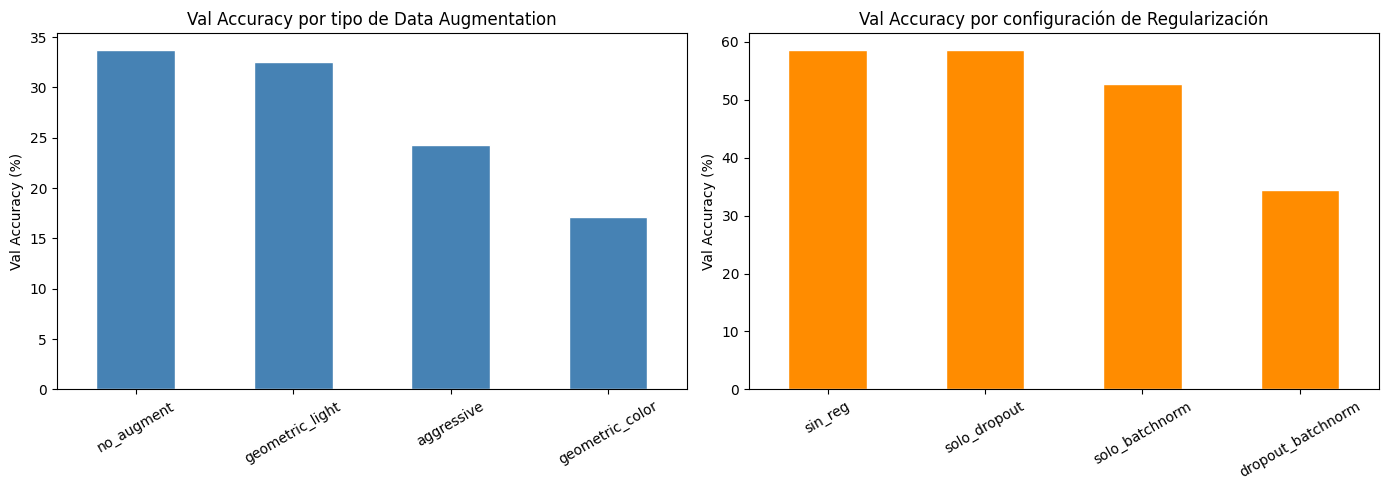

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

augment_series = pd.Series(augment_results).sort_values(ascending=False)
augment_series.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Val Accuracy por tipo de Data Augmentation")
axes[0].set_ylabel("Val Accuracy (%)")
axes[0].tick_params(axis='x', rotation=30)

reg_series = pd.Series(reg_results).sort_values(ascending=False)
reg_series.plot(kind="bar", ax=axes[1], color="darkorange", edgecolor="white")
axes[1].set_title("Val Accuracy por configuración de Regularización")
axes[1].set_ylabel("Val Accuracy (%)")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig("resumen_experimentos.png", bbox_inches="tight")
plt.show()